## **Import libraries**

In [1]:
import os
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)
from SARVI.models.losses import (
    MoMLoss
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)
from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner
)
from SARVI.services.common.icd_pred_funcs import(
    initialize_icd10_no_hs_head_model
)
from SARVI.services.sync_funcs.icd_pred_funcs import (
    prepare_data as prepare_data_SYNC,
    construct_loaders_icd, run_icd_classifier
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-06-08 00:17:31] INFO SentenceTransformer.py:219: Use pytorch device_name: cuda:0
[2026-06-08 00:17:31] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="CodiEsp/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run ICD data creation**

### **Create data**

In [4]:
print("1.1. Creating ICD data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train)

print("1.1. Creating ICD data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "CodiEsp/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "CodiEsp/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev)

1.1. Creating ICD data // Train data


Preparing data for ICD10 prediction:   0%|          | 0/500 [00:00<?, ?text/s]

1.1. Creating ICD data // Dev data


Preparing data for ICD10 prediction:   0%|          | 0/250 [00:00<?, ?text/s]

In [5]:
data_prepared_train.keys()

dict_keys(['diagnoses', 'file_names', 'icd_codes'])

### **Load tree**

In [4]:
df_reference = pd.read_excel(paths.docs_dir / "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores")

node_list = {"2026": load_tree_hierarchical_module(df_reference)}
root = node_list["2026"]["root"]
root.set_indexes()

Hierarchical tree construction: Cleaning data:   0%|          | 0/102448 [00:00<?, ?code/s]

3035

### **Create DataLoaders and models**

In [7]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_icd(data_prepared_train, all_window_labels_train, file_names_train, seed=SEED, batch_size=512, hs=False, root=root)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_icd(data_prepared_dev, all_window_labels_dev, file_names_dev, label2id=label2id, id2label=id2label, seed=SEED, batch_size=512, hs=False, root=root)

model_icd10_head = initialize_icd10_no_hs_head_model(ctx, model_ner, tokenizer_ner, None, label2id, root, freeze_encoder=False)
model_icd10_prediction = None

optimizer = torch.optim.AdamW(model_icd10_head.parameters(), lr=2e-5, weight_decay=0.001)
criterion = nn.CrossEntropyLoss()

Gathering diags definitions: Embedding definitions:   0%|          | 0/1917 [00:00<?, ?diag/s]

In [8]:
seed_everything(SEED)

print("1.2. Running ICD model // NO HS")
results = run_icd_classifier(model_icd10_head, data_loader_full_train, ctx.device, id2label, hs=False, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=300, ignore_index=-100, patience=25, return_predictions=True)

write_torch_checkpoint(ctx=ctx, name="ICDTraining/NO_HS/icd_pred_nohs_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="ICDTraining/NO_HS/icd_pred_nohs_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="ICDTraining/NO_HS/id2label_icd_pred_nohs", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="ICDTraining/NO_HS/label2id_icd_pred_nohs", content=label2id)

1.2. Running ICD model // NO HS


ICD10 NO HS / Training:   0%|          | 0/300 [00:00<?, ?epoch/s]

ICD10 NO HS / Training epoch 1 / Train set:   0%|          | 0/15 [00:00<?, ?batch/s]

ICD10 NO HS / Training epoch 1 / Dev set:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch 1/300 | train loss: 37.941066 | dev loss: 7.515968 | Precision (macro): 0.0002 | Precision (micro): 0.0376 | Recall (macro): 0.0026 | Recall (micro): 0.0376 | F1 (macro): 0.0003 | F1 (micro): 0.0376 | Best F1 (micro): 0.0376


...

ICD10 NO HS / Training epoch 151 / Dev set:   0%|          | 0/7 [00:00<?, ?batch/s]

Epoch 151/300 | train loss: 16.791806 | dev loss: 7.246188 | Precision (macro): 0.4471 | Precision (micro): 0.7088 | Recall (macro): 0.4574 | Recall (micro): 0.7088 | F1 (macro): 0.4315 | F1 (micro): 0.7088 | Best F1 (micro): 0.7106


ICD10 NO HS / Training epoch 152 / Train set:   0%|          | 0/15 [00:00<?, ?batch/s]

ICD10 NO HS / Training epoch 152 / Dev set:   0%|          | 0/7 [00:00<?, ?batch/s]


Early stopping at epoch 152 | Best epoch: 127 | Best dev F1 (micro): 0.710580


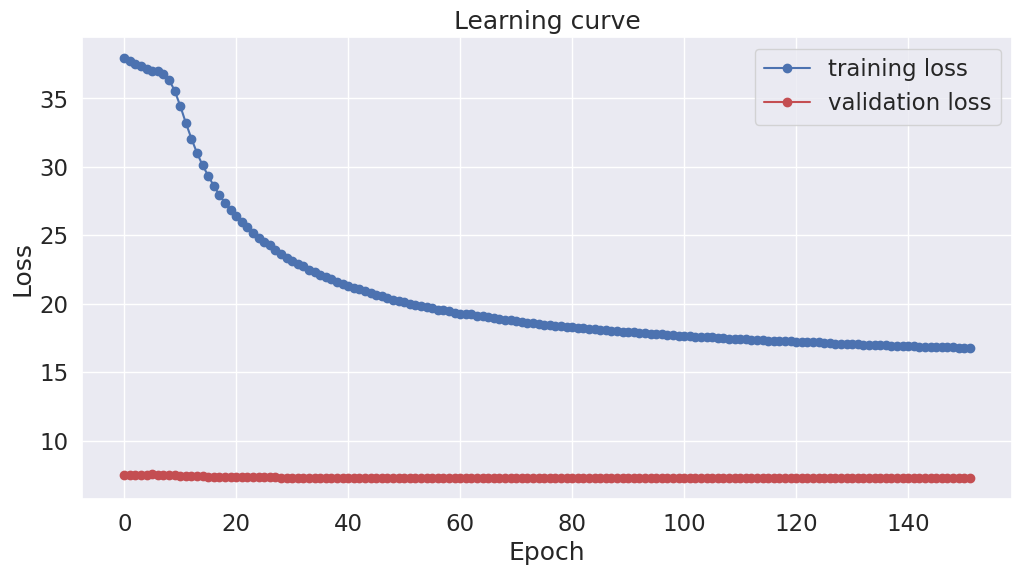

In [9]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [5]:
print("1.1. Creating ICD data // Test data")
dict_data_test = read_txt_list(ctx.paths.data_input / "CodiEsp/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

dict_ann_test = read_ann_list(ctx.paths.data_input / "CodiEsp/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test)

1.1. Creating ICD data // Test data


Preparing data for ICD10 prediction:   0%|          | 0/250 [00:00<?, ?text/s]

In [7]:
id2label = read_json_single(ctx.paths.docs_dir / "ICDTraining/NO_HS/id2label_icd_pred_nohs.json")
label2id = read_json_single(ctx.paths.docs_dir / "ICDTraining/NO_HS/label2id_icd_pred_nohs.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loaders_icd(data_prepared_test, all_window_labels_test, file_names_test, label2id=label2id, id2label=id2label, seed=SEED, batch_size=512, hs=False, root=root)

model_icd10_head = initialize_icd10_no_hs_head_model(ctx, model_ner, tokenizer_ner, ctx.paths.docs_dir / "ICDTraining/NO_HS/icd_pred_nohs_checkpoint.pt", label2id, root)
model_icd10_prediction = None

Gathering diags definitions: Embedding definitions:   0%|          | 0/1917 [00:00<?, ?diag/s]

In [8]:
results = run_icd_classifier(model_icd10_head, data_loader_full_test, ctx.device, id2label, hs=False, train=False)

ICD10 NO HS / Inference:   0%|          | 0/8 [00:00<?, ?batch/s]

Precision (macro): 0.4494 | Precision (micro): 0.7293 | Recall (macro): 0.4755 | Recall (micro): 0.7293 | F1 (macro): 0.4425 | F1 (micro): 0.7293
